# Fuel Price EDA

Exploratory analysis of `data/silver/prices_silver.parquet`.
One row = one unique price-change event, enriched with station details.

Sections: grade coverage, price distributions, brand, station type, price staleness, regional patterns, diesel-petrol spread.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("data/silver/prices_silver.parquet")
n_rows, n_stations = len(df), df["node_id"].nunique()
print(f"Rows: {n_rows:,}  |  Unique stations: {n_stations:,}")
df.head(3)

Rows: 48,501  |  Unique stations: 7,973


,node_id,fuel_type,price_ppl,price_change_effective_timestamp,price_last_updated,first_seen_at,pfs_snapshot_used,brand_name,trading_name,postcode,latitude,longitude,city,county,country,is_motorway,is_supermarket,temporary_closure,permanent_closure
0,00008759c79a869b9f324a75570897e003020b74a97383...,B7_STANDARD,171.9,2026-06-19 16:35:01+00:00,2026-06-19 16:12:04.497000+00:00,2026-06-24 15:24:54.918014+00:00,2026-06-24 15:24:54.918014+00:00,Tesco,HARROGATE - PETROL FILLING STATION,HG1 3DW,54.0064,-1.5514,HARROGATE,,England,False,False,False,False
1,00008759c79a869b9f324a75570897e003020b74a97383...,B7_STANDARD,167.9,2026-06-25 15:14:29+00:00,2026-06-25 15:21:16.203000+00:00,2026-06-25 15:30:01.231386+00:00,2026-06-25 15:30:01.231386+00:00,Tesco,HARROGATE - PETROL FILLING STATION,HG1 3DW,54.0064,-1.5514,HARROGATE,,England,False,False,False,False
2,00008759c79a869b9f324a75570897e003020b74a97383...,B7_STANDARD,162.9,2026-06-30 16:51:04+00:00,2026-06-30 16:51:06.013000+00:00,2026-06-30 18:01:09.276232+00:00,2026-06-30 18:01:09.276232+00:00,Tesco,HARROGATE - PETROL FILLING STATION,HG1 3DW,54.0064,-1.5514,HARROGATE,,England,False,False,False,False


## 1. Grade coverage

How many stations sell each grade? Establishes what we can actually model.

In [2]:
grade_counts = (
    df.groupby("fuel_type")["node_id"]
    .nunique()
    .sort_values(ascending=False)
    .rename("stations")
    .reset_index()
)
total = df["node_id"].nunique()
grade_counts["pct_of_all_stations"] = (grade_counts["stations"] / total * 100).round(1)
grade_counts

,fuel_type,stations,pct_of_all_stations
0,B7_STANDARD,7875,98.8
1,E10,7793,97.7
2,E5,6200,77.8
3,B7_PREMIUM,4126,51.7
4,HVO,71,0.9
5,B10,58,0.7


## 2. Price distributions

Current E10 and B7_STANDARD price distributions across all stations.
Dashed line = mean, dotted = median.

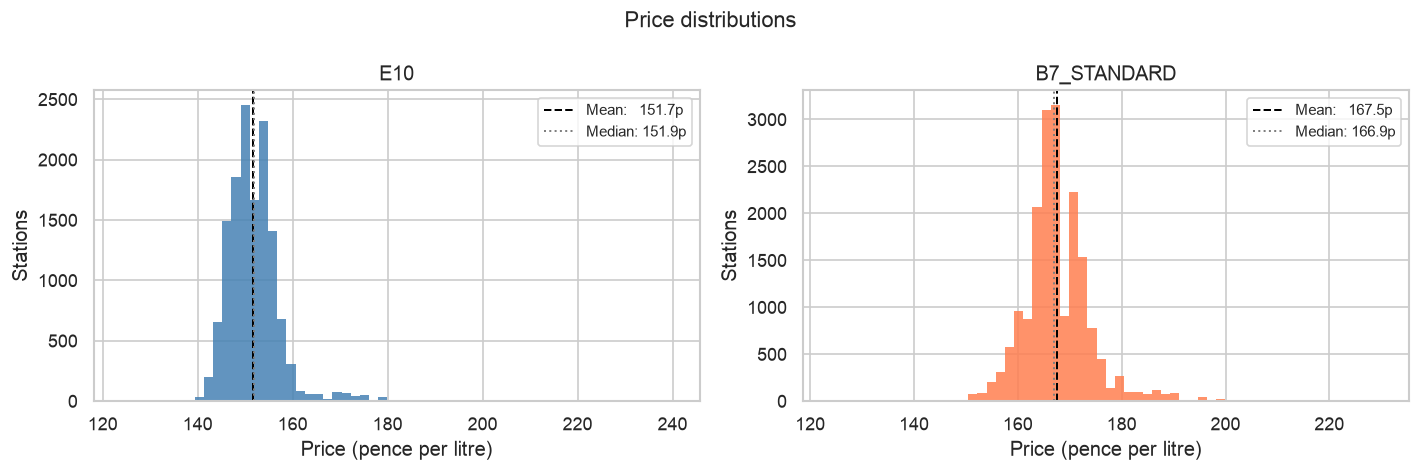


E10
count    13603.00
mean       151.73
std          5.47
min        123.90
25%        148.90
50%        151.90
75%        153.90
max        239.90

B7_STANDARD
count    18386.00
mean       167.51
std          6.47
min        123.90
25%        163.90
50%        166.90
75%        169.90
max        230.00


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, grade, color in zip(axes, ["E10", "B7_STANDARD"], ["steelblue", "coral"]):
    data = df.loc[df["fuel_type"] == grade, "price_ppl"].dropna()
    ax.hist(data, bins=60, color=color, edgecolor="none", alpha=0.85)
    mean, median = data.mean(), data.median()
    ax.axvline(mean,   color="black", linestyle="--", lw=1.2, label=f"Mean:   {mean:.1f}p")
    ax.axvline(median, color="grey",  linestyle=":",  lw=1.2, label=f"Median: {median:.1f}p")
    ax.set_title(grade)
    ax.set_xlabel("Price (pence per litre)")
    ax.set_ylabel("Stations")
    ax.legend(fontsize=9)

fig.suptitle("Price distributions", fontsize=13)
plt.tight_layout()
plt.show()

for grade in ["E10", "B7_STANDARD"]:
    print()
    print(grade)
    print(df.loc[df["fuel_type"] == grade, "price_ppl"].describe().round(2).to_string())

## 3. Brand analysis

Median E10 price for the 20 largest brands by station count.
The fair-price model needs to control for brand: supermarkets structurally price below independents.

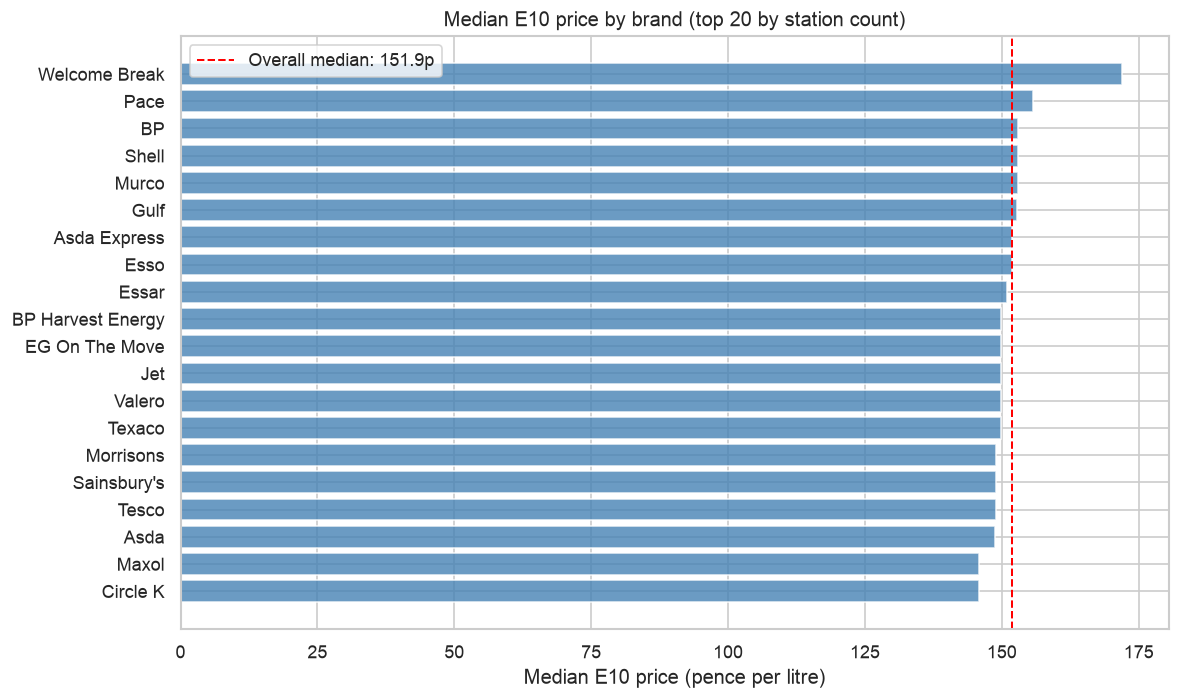

       brand_name  stations  mean  median  std
         Circle K        66 146.0   145.9  5.3
            Maxol       168 146.4   145.9  2.1
             Asda       596 148.7   148.7  3.1
            Tesco       900 149.0   148.9  3.2
        Morrisons       662 148.7   148.9  2.7
      Sainsbury's       534 149.2   148.9  3.4
BP Harvest Energy        62 151.2   149.9  3.0
           Texaco       879 150.7   149.9  4.1
              Jet       530 150.8   149.9  3.5
   EG On The Move       301 150.0   149.9  2.9
           Valero       204 150.5   149.9  3.7
            Essar        69 151.6   150.9  3.7
     Asda Express       101 151.9   151.9  3.3
             Esso      2409 151.9   151.9  3.9
             Gulf       442 153.3   152.8  4.9
            Shell      1540 153.4   152.9  4.5
               BP      1826 153.9   152.9  6.0
            Murco       232 152.9   152.9  5.0
             Pace        66 155.7   155.7  5.3
    Welcome Break       103 169.1   171.9  9.9


In [4]:
e10 = df[df["fuel_type"] == "E10"].dropna(subset=["brand_name"])

brand_stats = (
    e10.groupby("brand_name")["price_ppl"]
    .agg(stations="count", mean="mean", median="median", std="std")
    .reset_index()
)
top20 = brand_stats.nlargest(20, "stations")["brand_name"]
plot_data = brand_stats[brand_stats["brand_name"].isin(top20)].sort_values("median")

overall_median = e10["price_ppl"].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["brand_name"], plot_data["median"], color="steelblue", alpha=0.8)
ax.axvline(overall_median, color="red", lw=1.2, linestyle="--",
           label=f"Overall median: {overall_median:.1f}p")
ax.set_xlabel("Median E10 price (pence per litre)")
ax.set_title("Median E10 price by brand (top 20 by station count)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    brand_stats.nlargest(20, "stations")
    [["brand_name", "stations", "mean", "median", "std"]]
    .sort_values("median")
    .round(1)
    .to_string(index=False)
)

## 4. Station type: motorway vs supermarket vs independent

Three structurally different groups with different cost bases and customer captivity.
The model must treat them separately.

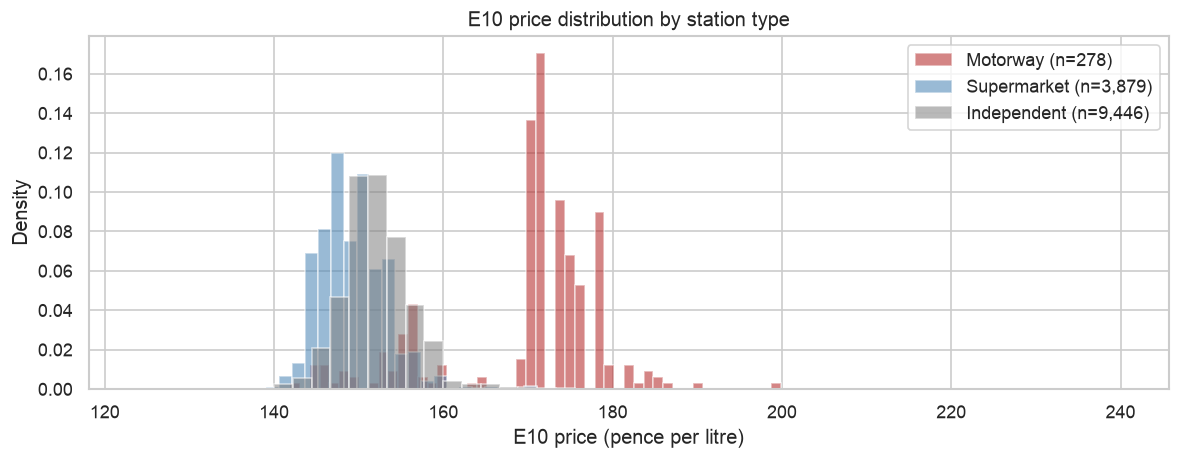

               count    mean   std    min    25%    50%    75%    max
station_type                                                         
Independent   9446.0  152.20  4.57  128.9  149.9  151.9  154.7  239.9
Motorway       278.0  169.93  9.43  141.9  169.9  171.9  174.9  199.9
Supermarket   3879.0  149.26  4.19  123.9  146.7  148.9  151.9  199.9

In [5]:
e10 = df[df["fuel_type"] == "E10"].copy()

def label_type(row):
    if row["is_motorway"] is True:
        return "Motorway"
    if row["is_supermarket"] is True:
        return "Supermarket"
    return "Independent"

e10["station_type"] = e10.apply(label_type, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
palette = {"Motorway": "firebrick", "Supermarket": "steelblue", "Independent": "grey"}
for stype, color in palette.items():
    data = e10.loc[e10["station_type"] == stype, "price_ppl"]
    ax.hist(data, bins=50, alpha=0.55,
            label=f"{stype} (n={len(data):,})", color=color, density=True)

ax.set_xlabel("E10 price (pence per litre)")
ax.set_ylabel("Density")
ax.set_title("E10 price distribution by station type")
ax.legend()
plt.tight_layout()
plt.show()

print(e10.groupby("station_type")["price_ppl"].describe().round(2))

## 5. Price staleness

How long ago did each station last change its price?
Stations that rarely change are less useful for modelling price dynamics.

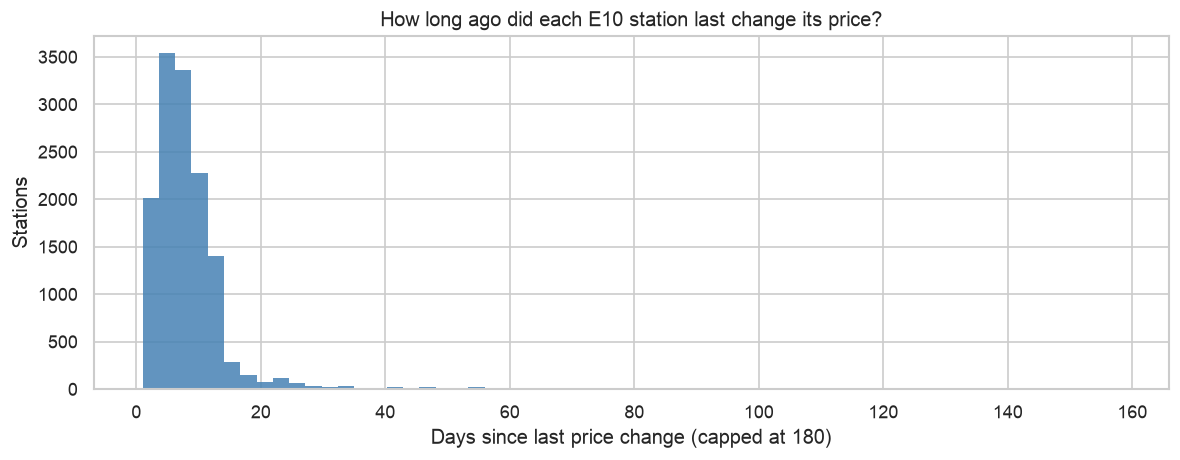

count    13603.0
mean         8.7
std          9.3
min          1.0
25%          5.0
50%          7.0
75%          9.0
max        158.0

Unchanged for >30 days : 270
Unchanged for >7 days  : 6,401
Changed within 24h     : 810


In [6]:
now = pd.Timestamp.now(tz="UTC")
e10 = df[df["fuel_type"] == "E10"].copy()
e10["days_since_change"] = (now - e10["price_change_effective_timestamp"]).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(e10["days_since_change"].clip(upper=180), bins=60,
        color="steelblue", alpha=0.85, edgecolor="none")
ax.set_xlabel("Days since last price change (capped at 180)")
ax.set_ylabel("Stations")
ax.set_title("How long ago did each E10 station last change its price?")
plt.tight_layout()
plt.show()

d = e10["days_since_change"]
print(d.describe().round(1).to_string())
print()
print(f"Unchanged for >30 days : {(d > 30).sum():,}")
print(f"Unchanged for >7 days  : {(d > 7).sum():,}")
print(f"Changed within 24h     : {(d <= 1).sum():,}")

## 6. Regional patterns

Average E10 price by country. A national model may need country-level fixed effects if regional variation is large.

In [7]:
country_stats = (
    df[df["fuel_type"] == "E10"]
    .dropna(subset=["country"])
    .groupby("country")["price_ppl"]
    .agg(stations="count", mean="mean", median="median", std="std")
    .sort_values("median", ascending=False)
    .reset_index()
)
print("E10 prices by country")
print()
print(country_stats.round(2).to_string(index=False))

E10 prices by country

         country  stations   mean  median  std
        Scotland      1268 153.84   152.9 6.41
         England     10727 151.91   151.9 5.30
           Wales       756 151.39   150.9 4.17
        UK Other        71 149.87   148.9 3.92
Northern Ireland       781 146.22   145.9 3.60


## 7. Diesel-petrol spread (B7_STANDARD minus E10)

For stations selling both grades: how much more expensive is diesel?
A consistent spread suggests a structural premium. Negative values are anomalies.

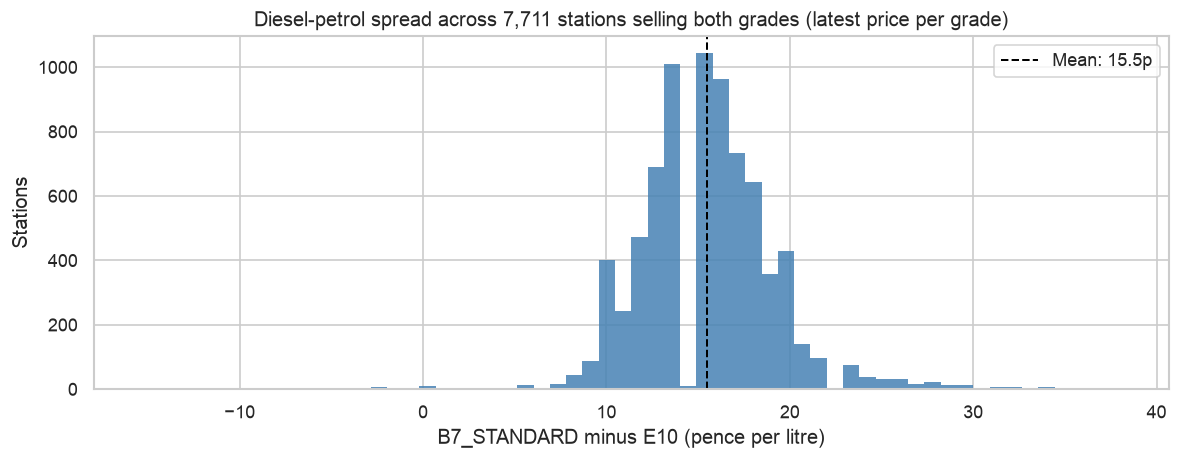

Spread (B7_STANDARD - E10, pence per litre), latest price per station per grade
count    7711.00
mean       15.48
std         3.86
min       -15.30
25%        13.00
50%        15.00
75%        18.00
max        38.00

Stations where diesel < petrol: 23


In [8]:
latest = (
    df.sort_values("price_change_effective_timestamp")
    .groupby(["node_id", "fuel_type"])
    .tail(1)
)
e10_p = (
    latest[latest["fuel_type"] == "E10"][["node_id", "price_ppl"]]
    .rename(columns={"price_ppl": "e10"})
)
b7_p = (
    latest[latest["fuel_type"] == "B7_STANDARD"][["node_id", "price_ppl"]]
    .rename(columns={"price_ppl": "b7"})
)
spread = e10_p.merge(b7_p, on="node_id")
spread["spread_ppl"] = spread["b7"] - spread["e10"]

mean_spread = spread["spread_ppl"].mean()
n_both = len(spread)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(spread["spread_ppl"], bins=60, color="steelblue", alpha=0.85, edgecolor="none")
ax.axvline(mean_spread, color="black", lw=1.2, linestyle="--",
           label=f"Mean: {mean_spread:.1f}p")
ax.set_xlabel("B7_STANDARD minus E10 (pence per litre)")
ax.set_ylabel("Stations")
ax.set_title(f"Diesel-petrol spread across {n_both:,} stations selling both grades (latest price per grade)")
ax.legend()
plt.tight_layout()
plt.show()

print("Spread (B7_STANDARD - E10, pence per litre), latest price per station per grade")
print(spread["spread_ppl"].describe().round(2).to_string())
print()
n_negative = (spread["spread_ppl"] < 0).sum()
print(f"Stations where diesel < petrol: {n_negative}")